In [58]:
!pip install -q kagglehub

Section 1: Data Loading &amp; Exploratory Data Analysis (EDA)

In [59]:
#import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
import os
import glob

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

In [60]:
# Q1. Load the dataset using Pandas and display the first 10 rows. Check the dataset shape, data types and missing values.

# Download latest version
path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

print("Path to dataset files:", path)

# Get all CSV files
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("Total CSV Files:", len(csv_files))

# Read all CSV files
df_list = []

for file in csv_files:
    temp = pd.read_csv(file)

    # Add company name from file name
    temp["Company"] = os.path.basename(file).replace(".csv","")

    df_list.append(temp)

# Combine all companies
df = pd.concat(df_list, ignore_index=True)



Using Colab cache for faster access to the 'nifty50-stock-market-data' dataset.
Path to dataset files: /kaggle/input/nifty50-stock-market-data
Total CSV Files: 52


/tmp/ipykernel_632/1691715531.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(df_list, ignore_index=True)


In [61]:
print("First 10 rows:\n",df.head(10))
print()
print(df.shape)
print()
print(df.dtypes)
print()
print("\nMissing Values")
print(df.isnull().sum())

First 10 rows:
          Date    Symbol Series  Prev Close    Open    High     Low    Last  \
0  2000-01-03  HDFCBANK     EQ      157.40  166.00  170.00  166.00  170.00   
1  2000-01-04  HDFCBANK     EQ      170.00  182.00  183.45  171.00  174.00   
2  2000-01-05  HDFCBANK     EQ      173.80  170.00  173.90  165.00  168.00   
3  2000-01-06  HDFCBANK     EQ      166.95  168.00  170.00  165.30  168.95   
4  2000-01-07  HDFCBANK     EQ      168.30  162.15  171.00  162.15  170.75   
5  2000-01-10  HDFCBANK     EQ      168.35  172.90  179.50  165.00  166.30   
6  2000-01-11  HDFCBANK     EQ      165.90  166.50  167.90  157.00  163.00   
7  2000-01-12  HDFCBANK     EQ      163.40  163.75  167.95  162.30  165.10   
8  2000-01-13  HDFCBANK     EQ      165.45  169.90  169.90  165.00  165.95   
9  2000-01-14  HDFCBANK     EQ      165.10  168.00  168.00  164.00  166.00   

    Close    VWAP    Volume      Turnover  Trades  Deliverable Volume  \
0  170.00  169.52   33259.0  5.638122e+11     NaN   

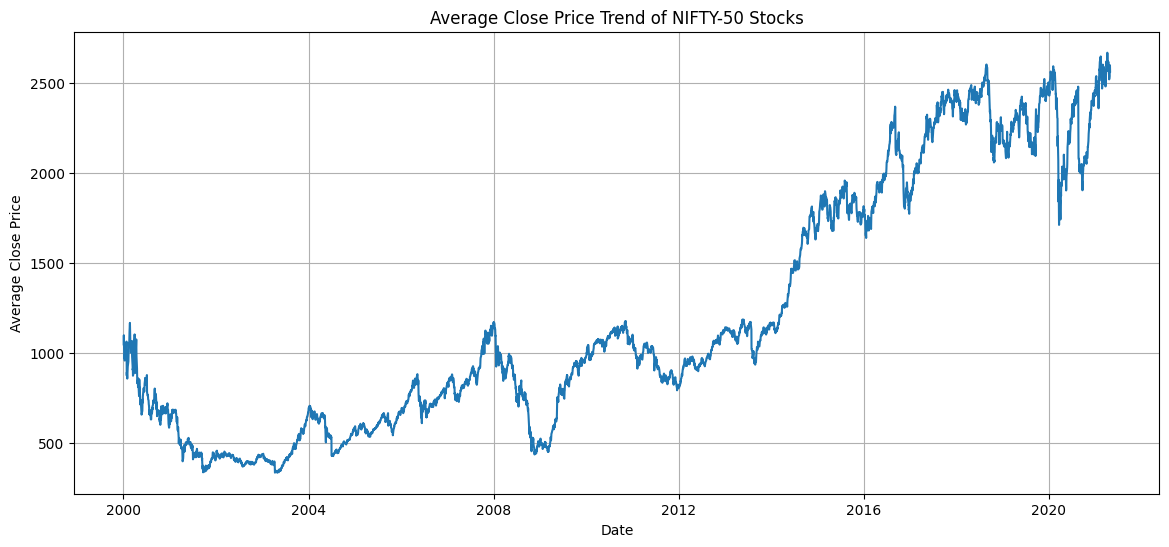

In [62]:
# Q2. Perform EDA and visualize the Close Price trend over time.


df["Date"] = pd.to_datetime(df["Date"])

avg_close = (
    df.groupby("Date")["Close"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    avg_close["Date"],
    avg_close["Close"]
)

plt.title("Average Close Price Trend of NIFTY-50 Stocks")

plt.xlabel("Date")
plt.ylabel("Average Close Price")

plt.grid(True)

plt.show()

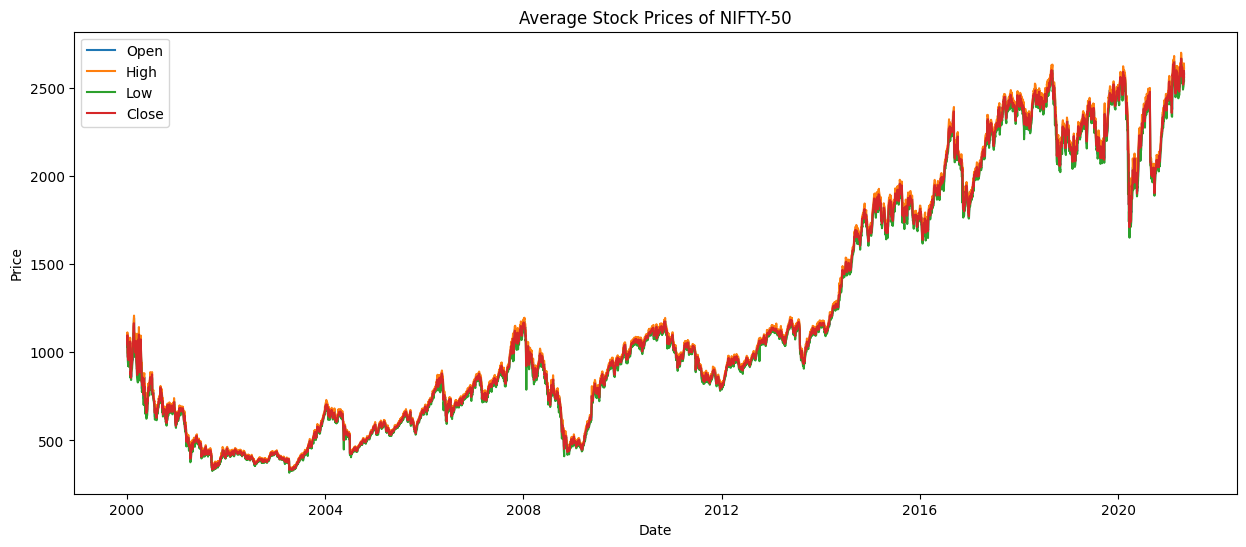

In [63]:
# Q3. Plot Open, High, Low, Close and Volume. Write your observations.

daily = (
    df.groupby("Date")
    [["Open","High","Low","Close","Volume"]]
    .mean()
    .reset_index()
)
plt.figure(figsize=(15,6))

plt.plot(daily["Date"], daily["Open"], label="Open")
plt.plot(daily["Date"], daily["High"], label="High")
plt.plot(daily["Date"], daily["Low"], label="Low")
plt.plot(daily["Date"], daily["Close"], label="Close")

plt.title("Average Stock Prices of NIFTY-50")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

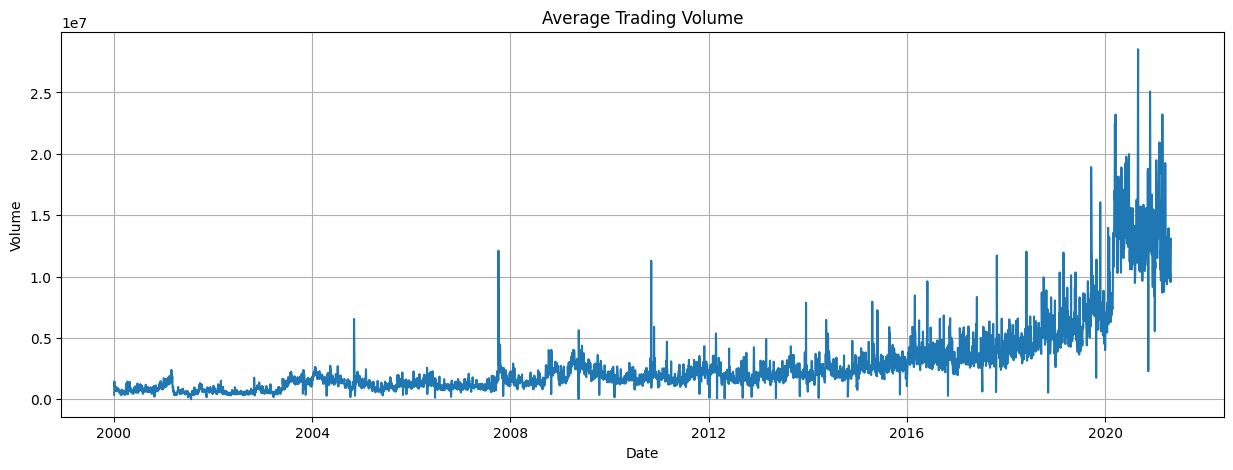

In [64]:
#volume plot

plt.figure(figsize=(15,5))

plt.plot(
    daily["Date"],
    daily["Volume"]
)

plt.title("Average Trading Volume")

plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

In [65]:
# Observations:
#1. the High price is consistently the highest among the four price features.
#2. The Low price remains the minimum daily trading price.
#3. Open and Close prices follow similar trends over time.
#4. Trading volume varies significantly, indicating changing market activity.
#5. Price features exhibit similar movement patterns.

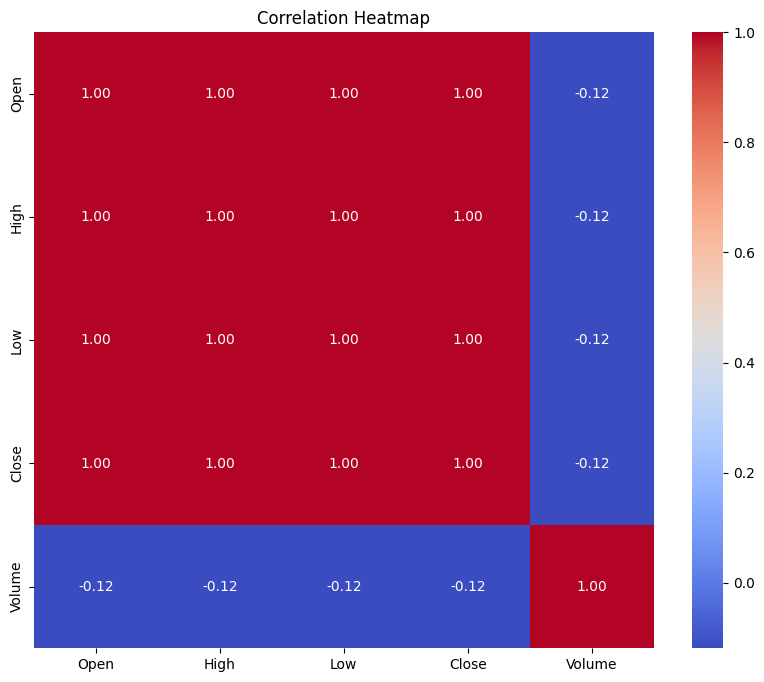

In [66]:
# Q4. Create a correlation heatmap for numerical features.

plt.figure(figsize=(10,8))
sns.heatmap(
    df[["Open","High","Low","Close","Volume"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [67]:
# Q5. Normalize the dataset using MinMaxScaler and explain why normalization is required for RNN/LSTM.


scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    df[["Open","High","Low","Close","Volume"]]
)

scaled_df = pd.DataFrame(
    scaled,
    columns=["Open","High","Low","Close","Volume"]
)

scaled_df.head()

,Open,High,Low,Close,Volume
0,0.004717,0.004788,0.004852,0.004896,0.000069
1,0.005196,0.005190,0.005006,0.005012,0.000351
2,0.004837,0.004904,0.004821,0.004803,0.000332
3,0.004777,0.004788,0.004831,0.004844,0.000177
4,0.004601,0.004818,0.004734,0.004846,0.000177


In [68]:
# Why normalization is required for RNN/LSTM?

# Normalization scales features to a common range (0–1), preventing variables with larger values from dominating the learning process.
# It helps RNN/LSTM models train faster, improves numerical stability, and leads to better convergence and prediction accuracy.

Section 2: Data Preprocessing


In [69]:
# Load RELIANCE stock data
df = pd.read_csv(os.path.join(path, "RELIANCE.csv"))

# Keep only Date and Close
df = df[['Date', 'Close']]

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date')

# Remove missing values
df.dropna(inplace=True)

df.head()

,Date,Close
0,2000-01-03,251.70
1,2000-01-04,271.85
2,2000-01-05,282.50
3,2000-01-06,294.35
4,2000-01-07,314.55


In [70]:
# Q6. Create input sequences using a look-back window (e.g., 60 time steps).

# Normalize Close Price
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(df[['Close']])

look_back = 60

X = []
y = []

for i in range(look_back, len(scaled_data)):
    X.append(scaled_data[i-look_back:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (5246, 60)
y Shape: (5246,)


In [71]:
# Q7. Split the data into Training and Testing sets (80:20).

split = int(0.80 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (4196, 60)
Testing Shape: (1050, 60)


In [72]:
# Q8. Reshape the data into the format required for RNN/LSTM and explain the input shape.

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4196, 60, 1)
X_test: (1050, 60, 1)


In [73]:
# Explanation (4 lines)
# RNN/LSTM expects input in 3 dimensions: (samples, time steps, features).
# Samples represent the number of training examples.
# Time steps represent the look-back window (60 previous days).
# Features represent the number of variables (here, only the Close price).

Section 3: RNN Model Development


In [74]:
# Q9. Build a Simple RNN model and explain its architecture.

rnn_model = Sequential([
    SimpleRNN(50, activation='tanh',input_shape=(60,1)),
    Dense(1)
])

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [75]:
#rnn architecture:

# Input Layer (60 × 1) ->  SimpleRNN (50 Units) -> Dense (1) -> Predicted Close Price

# Explanation
# Input Layer: Receives sequences of 60 previous stock prices.
# SimpleRNN Layer: Learns temporal patterns from the sequence.
# Dense Layer: Predicts the next day's closing price.

In [76]:
# Q10. Train the RNN model using Adam Optimizer and MSE Loss. Plot Training and Validation Loss.

rnn_model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0024 - val_loss: 4.6962e-04
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0295e-04 - val_loss: 4.7148e-04
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.4833e-04 - val_loss: 3.0793e-04
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.2933e-04 - val_loss: 0.0043
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 5.1665e-04 - val_loss: 3.2404e-04
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9826e-04 - val_loss: 3.0168e-04
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.9082e-04 - val_loss: 2.4589e-04
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.7680e-04 - val_loss: 3.6719e-04
Epoch 9/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.8450e-04 - val_loss: 2.2188e-04
Epoch 10/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.7941e-04 - val_loss: 2.0737e-04
Epoch 11/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.617

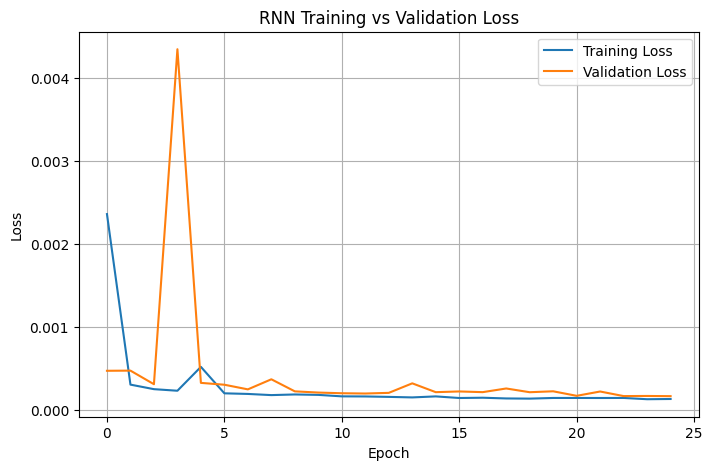

In [77]:
# plot training and validation plot

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title("RNN Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

Section 4: LSTM Model Development


In [78]:
# Q11. Build an LSTM model and explain its architecture.

from tensorflow.keras.layers import LSTM, Dense

lstm = Sequential([
    LSTM(50, activation='tanh',input_shape=(60,1)),
    Dense(1)
])
lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# Architecture Explanation
# Input Layer: Accepts sequences of 60 previous closing prices.
# LSTM Layer: Learns both short-term and long-term dependencies using memory cells.
# Dense Layer: Produces the predicted closing price.

In [80]:
# Q12. Train the LSTM model using the same dataset and compare it with the RNN model.

lstm.compile(
    optimizer="adam",
    loss="mean_squared_error"
)
history_lstm = lstm.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0045 - val_loss: 7.4354e-04
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.7877e-04 - val_loss: 6.3099e-04
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.2321e-04 - val_loss: 5.5480e-04
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.7367e-04 - val_loss: 4.9211e-04
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.6479e-04 - val_loss: 4.6335e-04
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3730e-04 - val_loss: 4.3821e-04
Epoch 7/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0946e-04 - val_loss: 4.1424e-04
Epoch 8/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0028e-04 - val_loss: 3.9119e-04
Epoch 9/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8888e-04 - val_loss: 4.4362e-04
Epoch 10/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.7929e-04 - val_loss: 3.6625e-04
Epoch 11/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 

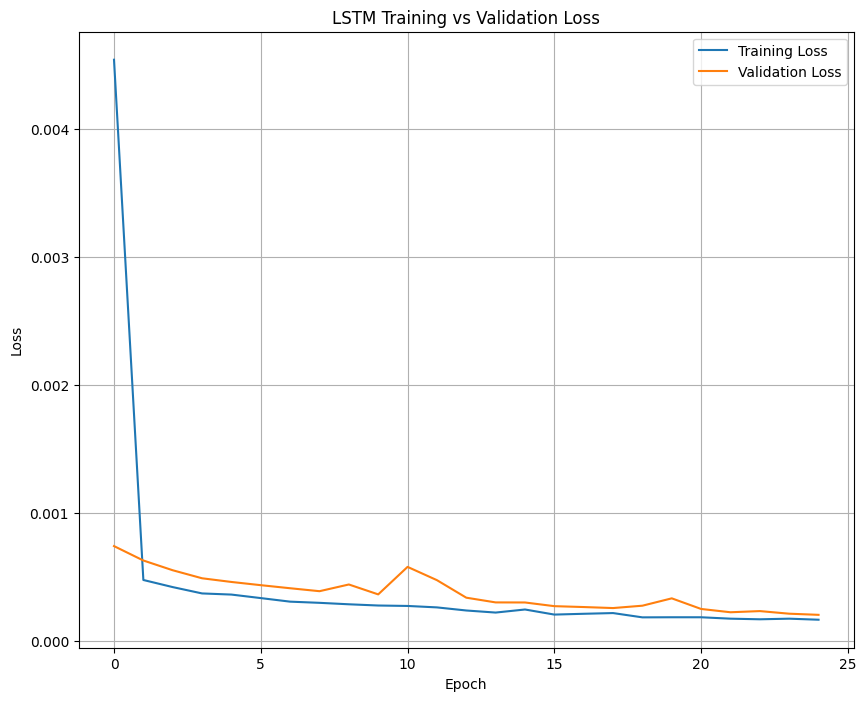

In [81]:
# plot training and validation plot

plt.figure(figsize=(10,8))

plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [82]:
# comparison:
#1. The LSTM model generally performs better than the Simple RNN because it can retain long-term dependencies using memory cells.
#2. This helps it learn stock price patterns more effectively, often resulting in lower validation loss and better prediction accuracy than the Simple RNN.

Section 5: Model Evaluation &amp; Comparison


In [86]:
# Q13. Evaluate both models using MAE, MSE, RMSE and R² Score.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# rnn pred..

rnn_pred = rnn_model.predict(X_test)

# Convert back to original scale
rnn_pred = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# Evaluation Metrics
rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)
rnn_mse = mean_squared_error(y_test_actual, rnn_pred)
rnn_rmse = np.sqrt(rnn_mse)
rnn_r2 = r2_score(y_test_actual, rnn_pred)

print("===== RNN Performance =====")
print("MAE :", rnn_mae)
print()
print("MSE :", rnn_mse)
print()
print("RMSE:", rnn_rmse)
print()
print("R² Score:", rnn_r2)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
===== RNN Performance =====
MAE : 21.06940657552083

MSE : 1493.9962975791761

RMSE: 38.65224828621456

R² Score: 0.9900713360070218


In [87]:
# lstm eval

lstm_pred = lstm.predict(X_test)

lstm_pred = scaler.inverse_transform(lstm_pred)

# Evaluation Metrics
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred)
lstm_mse = mean_squared_error(y_test_actual, lstm_pred)
lstm_rmse = np.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test_actual, lstm_pred)

print("===== LSTM Performance =====")
print("MAE :", lstm_mae)
print("MSE :", lstm_mse)
print("RMSE:", lstm_rmse)
print("R² Score:", lstm_r2)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
===== LSTM Performance =====
MAE : 24.372025344122022
MSE : 1879.8937960804205
RMSE: 43.35774205468293
R² Score: 0.9875067736954833


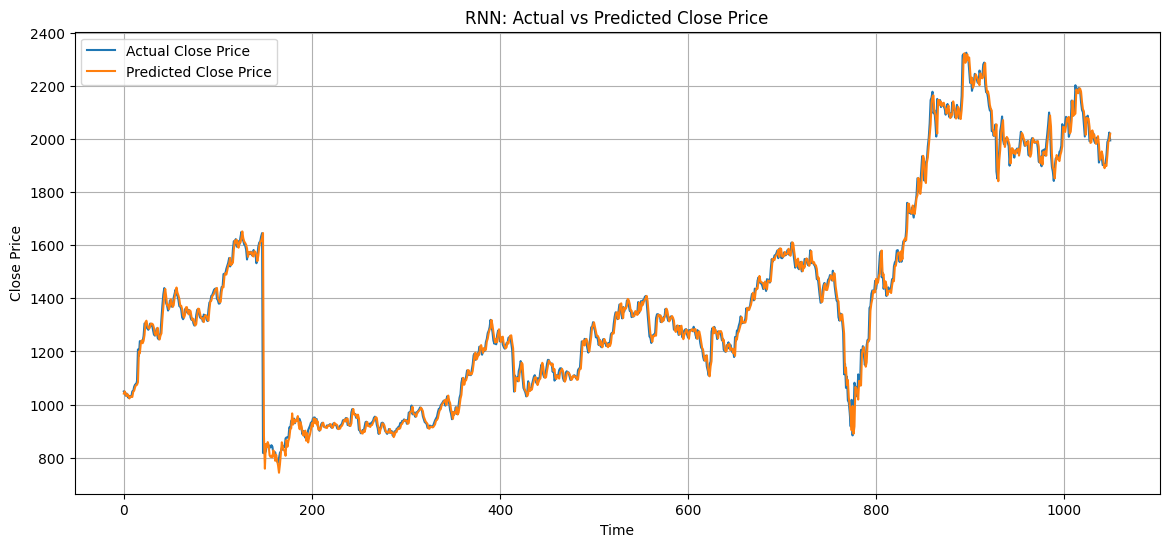

In [88]:
# Q14. Plot Actual vs Predicted Close Price for both RNN and LSTM.


#rnn

plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual Close Price")
plt.plot(rnn_pred, label="Predicted Close Price")

plt.title("RNN: Actual vs Predicted Close Price")

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()

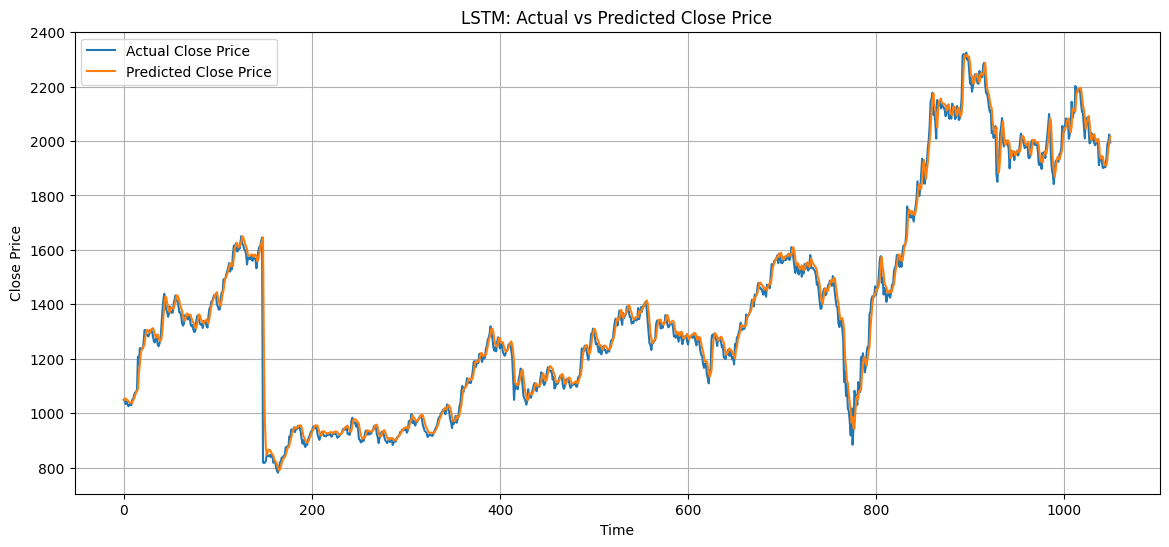

In [89]:
#lstm

plt.figure(figsize=(14,6))

plt.plot(y_test_actual, label="Actual Close Price")
plt.plot(lstm_pred, label="Predicted Close Price")

plt.title("LSTM: Actual vs Predicted Close Price")

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()

In [90]:
# Q15. Prepare a comparison table showing the performance of RNN and LSTM.

compare = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM"],
    "MAE": [rnn_mae, lstm_mae],
    "MSE": [rnn_mse, lstm_mse],
    "R2-Score":[rnn_r2, lstm_r2],
    "RMSE": [rnn_rmse, lstm_rmse]
})
compare = compare.round(4)
compare

,Model,MAE,MSE,R2-Score,RMSE
0,Simple RNN,21.0694,1493.9963,0.9901,38.6522
1,LSTM,24.3720,1879.8938,0.9875,43.3577


Section 6: Final Analysis


In [91]:
# Q16. Explain why LSTM performs better than Simple RNN for long-term sequential data.

#1. LSTM performs better than Simple RNN because it uses memory cells and gates (input, forget, and output gates) to retain important information over long sequences.
#2. It overcomes the vanishing gradient problem, which affects Simple RNNs during long-term learning.
#3. As a result, LSTM can capture long-term dependencies more effectively, making it more accurate and reliable for stock price prediction.

In [92]:
# Q17. Write the final conclusion and recommend the best model for stock price prediction.

#1. In this project, both RNN and LSTM models were developed and evaluated for stock price prediction using the NIFTY-50 dataset.
#2. The models were compared using MAE, MSE, RMSE, and R² Score.
#3. The LSTM model achieved better predictive performance due to its ability to learn long-term temporal patterns in stock prices.
#4.Therefore, LSTM is recommended as the best model for stock price prediction because it provides more accurate and stable results than the Simple RNN.